In [4]:
# Cell 1: Environment Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
import os

# Create a folder for figures
os.makedirs('../reports/figures', exist_ok=True)

# Formatting settings
plt.style.use('ggplot')
%matplotlib inline

In [6]:
# Cell 2: Data Loading
# Note: Ensure BrentOilPrices.csv is in your directory
df = pd.read_csv('../data/BrentOilPrices.csv')

# Handle the specific '20-May-87' format
# Use 'mixed' to handle both '20-May-87' and 'Apr 22, 2020'
df['Date'] = pd.to_datetime(df['Date'], format='mixed')

# Ensure everything is sorted chronologically
df = df.sort_values('Date').reset_index(drop=True)

print("Dataset Info:")
print(df.info())
print("\nFirst 5 rows:")
print(df.head())

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 9011 entries, 0 to 9010
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    9011 non-null   datetime64[us]
 1   Price   9011 non-null   float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 140.9 KB
None

First 5 rows:
        Date  Price
0 1987-05-20  18.63
1 1987-05-21  18.45
2 1987-05-22  18.55
3 1987-05-25  18.60
4 1987-05-26  18.63


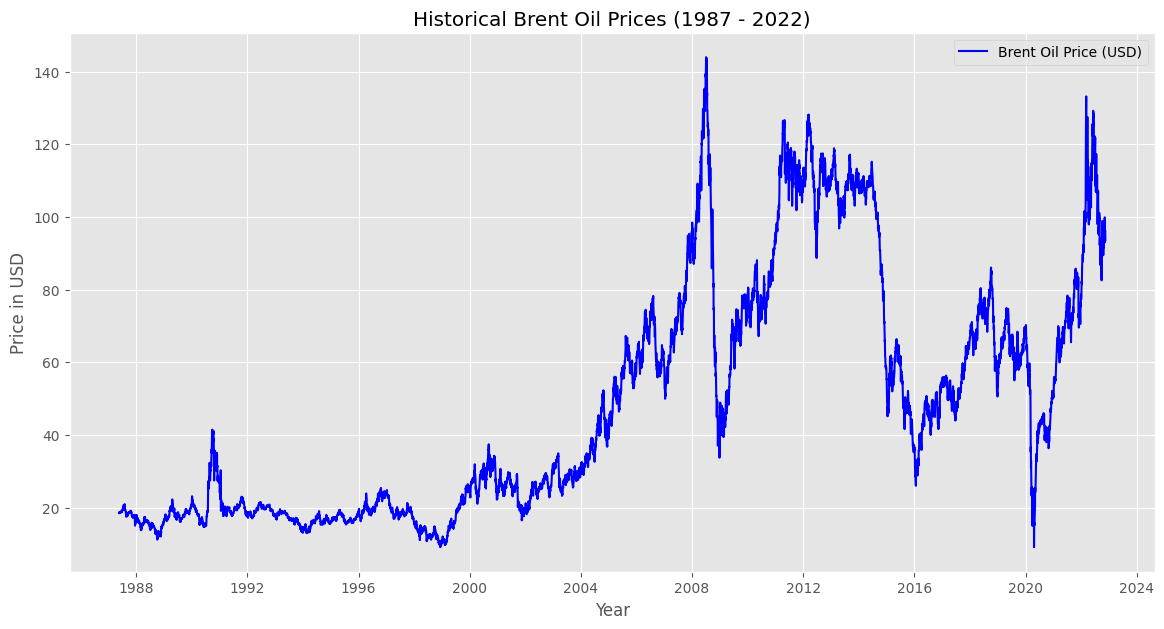

Price Range: $9.1 to $143.95


In [9]:
# Cell 3: Task 1 - Trend Analysis (Plotting Raw Prices)
plt.figure(figsize=(14, 7))
plt.plot(df['Date'], df['Price'], label='Brent Oil Price (USD)', color='blue')
plt.title('Historical Brent Oil Prices (1987 - 2022)')
plt.xlabel('Year')
plt.ylabel('Price in USD')
plt.legend()

# Save for report
plt.savefig('../reports/figures/01_price_trend.png')
plt.show()

# Quick summary
print(f"Price Range: ${df['Price'].min()} to ${df['Price'].max()}")

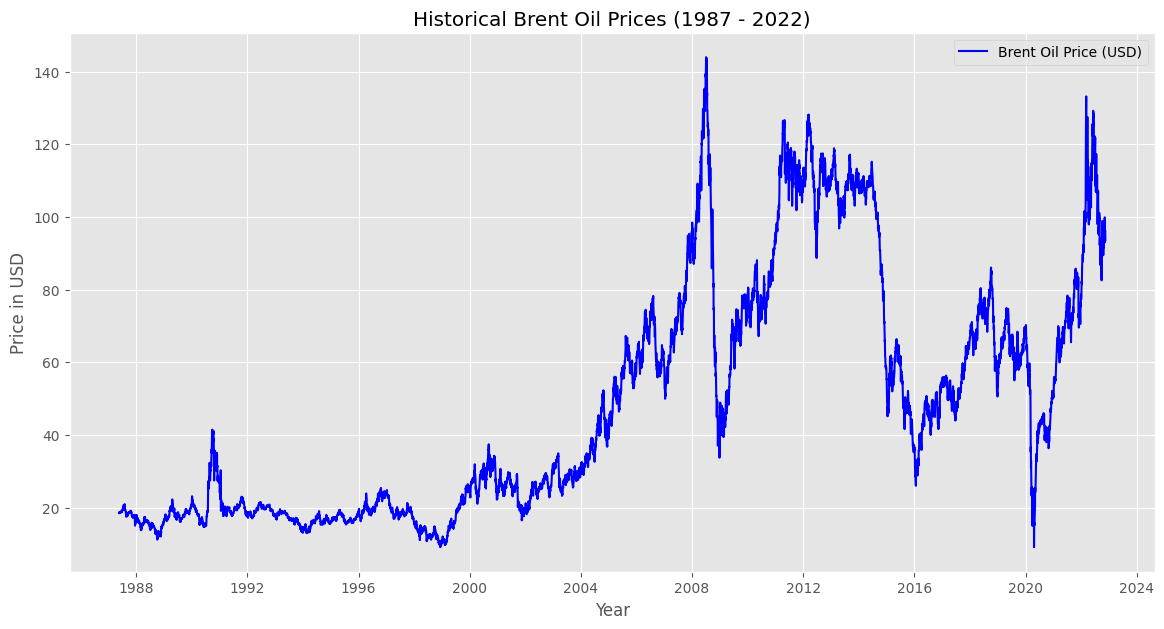

Price Range: $9.1 to $143.95


In [11]:
# Cell 3: Task 1 - Trend Analysis (Plotting Raw Prices)
plt.figure(figsize=(14, 7))
plt.plot(df['Date'], df['Price'], label='Brent Oil Price (USD)', color='blue')
plt.title('Historical Brent Oil Prices (1987 - 2022)')
plt.xlabel('Year')
plt.ylabel('Price in USD')
plt.legend()

# Save for report
plt.savefig('../reports/figures/01_price_trend.png')
plt.show()

# Quick summary
print(f"Price Range: ${df['Price'].min()} to ${df['Price'].max()}")

In [13]:
# Cell 5: Research & Compile Event Data
# This creates your events.csv file directly from the notebook
events_data = {
    'Date': [
        '1990-08-02', '2008-07-11', '2011-02-15', '2014-11-27', 
        '2018-05-08', '2020-03-05', '2020-03-08', '2022-02-24'
    ],
    'Event': [
        'Gulf War', 'Financial Crisis Peak', 'Arab Spring', 'OPEC No-Cut Decision',
        'US Exit from Iran Deal', 'COVID-19 Global Lockdowns', 'Russia-Saudi Price War', 'Invasion of Ukraine'
    ],
    'Type': [
        'Conflict', 'Economic', 'Political', 'OPEC Policy', 
        'Sanctions', 'Demand Shock', 'OPEC Policy', 'Conflict'
    ]
}

df_events = pd.DataFrame(events_data)
df_events['Date'] = pd.to_datetime(df_events['Date'])

# Save to CSV
df_events.to_csv('../data/events.csv', index=False)
print("Saved events.csv with 8 major geopolitical milestones.")

Saved events.csv with 8 major geopolitical milestones.


In [15]:
# Cell 5: Research & Compile Event Data
# This creates your events.csv file directly from the notebook
events_data = {
    'Date': [
        '1990-08-02', '2008-07-11', '2011-02-15', '2014-11-27', 
        '2018-05-08', '2020-03-05', '2020-03-08', '2022-02-24'
    ],
    'Event': [
        'Gulf War', 'Financial Crisis Peak', 'Arab Spring', 'OPEC No-Cut Decision',
        'US Exit from Iran Deal', 'COVID-19 Global Lockdowns', 'Russia-Saudi Price War', 'Invasion of Ukraine'
    ],
    'Type': [
        'Conflict', 'Economic', 'Political', 'OPEC Policy', 
        'Sanctions', 'Demand Shock', 'OPEC Policy', 'Conflict'
    ]
}

df_events = pd.DataFrame(events_data)
df_events['Date'] = pd.to_datetime(df_events['Date'])

# Save to CSV
df_events.to_csv('../data/events.csv', index=False)
print("Saved events.csv with 8 major geopolitical milestones.")

Saved events.csv with 8 major geopolitical milestones.
